In [ ]:
from cfg_tools import load_config_files

from numb_project.gw_model import MyGlobalWorkspace, get_global_workspace_params
from numb_project.data_module import MnistDataModule

config = load_config_files(
    f"/home/lucas/gwnumb/config",
    use_cli=False,
    load_files=["config.yaml"])[0]

gw_mod, selection_mod, loss_mod = get_global_workspace_params(config)

gw = MyGlobalWorkspace.load_from_checkpoint(
    "/home/lucas/gwnumb/checkpoints/numb/test.ckpt",
    gw_mod=gw_mod,
    selection_mod=selection_mod,
    loss_mod=loss_mod
    )

In [13]:
mnist_vae = gw.gw_mod.domain_mods.image.vae

In [ ]:
data_module = MnistDataModule(1024)

In [18]:
train_loader = data_module.train_dataloader()

image_batch shape: torch.Size([1024, 1, 28, 28])
mu shape: torch.Size([1024, 12])
reconstructed shape: torch.Size([1024, 1, 28, 28])
MSE reconstruction: 0.008974


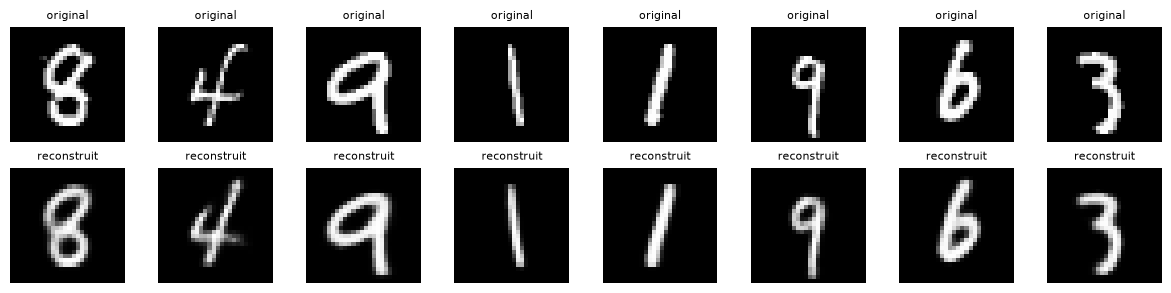

In [20]:
import matplotlib.pyplot as plt
import torch

train_loader = data_module.train_dataloader()
mnist_vae = gw.gw_mod.domain_mods.image.vae
mnist_vae.eval()

# Récupère un batch depuis le CombinedLoader
batch, batch_idx, dataloader_idx = next(iter(train_loader))

# Le batch est un dict {frozenset(...): {...}} — on va chercher celui qui contient "image"
image_batch = None
for key, value in batch.items():
    if "image" in value:
        image_batch = value["image"]
        break

if image_batch is None:
    raise ValueError("Aucune clé du batch ne contient 'image'")

print("image_batch shape:", image_batch.shape)

# Encode / decode
device = next(mnist_vae.parameters()).device
image_batch = image_batch.to(device)

with torch.no_grad():
    mu, logvar = mnist_vae.encoder(image_batch)
    reconstructed = mnist_vae.decoder(mu)

print("mu shape:", mu.shape)
print("reconstructed shape:", reconstructed.shape)

# Erreur de reconstruction (MSE)
mse = torch.nn.functional.mse_loss(reconstructed, image_batch)
print(f"MSE reconstruction: {mse.item():.6f}")

# Visualisation : originales vs reconstructions
n_show = min(8, image_batch.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.5, 3))

for i in range(n_show):
    axes[0, i].imshow(image_batch[i, 0].cpu().numpy(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(reconstructed[i, 0].cpu().numpy(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("reconstruit", fontsize=8)

plt.tight_layout()
plt.show()